In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("IVG_data.csv")

df = pd.DataFrame(data)
# print(df.head())

# Portfolio performance
df["YTD"] = (
    df["YTD"].astype(str)
    .str.strip()
    .str.replace("%", "")
    .replace("", "0")
    .astype(float)
    / 100
)

df["YOY"] = (
    df["YOY"].astype(str)
    .str.strip()
    .str.replace("%", "")
    .replace("", "0")
    .astype(float)
    / 100
)

df["Weighting"] = (
    df["Weighting"].astype(str)
    .str.strip()
    .str.replace("%", "")
    .replace("", "0")
    .astype(float)
    / 100
)

df["Weighted YTD Return"] = df["YTD"] * df["Weighting"]
df["Weighted YOY Return"] = df["YOY"] * df["Weighting"]

total_ytd_return = df["Weighted YTD Return"].sum()
total_yoy_return = df["Weighted YOY Return"].sum()

print(f"\nTotal Portfolio YTD Return: {total_ytd_return:.2%}")
print(f"Total Portfolio YOY Return: {total_yoy_return:.2%}\n")

# Portfolio value by type
df["Market Value"] = df["Market Value"].str.strip("$").str.replace(",", "").astype(float)
portfolio_value_by_type = df.groupby("Type")["Market Value"].sum()

type1 = portfolio_value_by_type.iloc[0]
type2 = portfolio_value_by_type.iloc[1]

portfolio_total = type1 + type2

print("Type distribution:")
print(f"  Type 1: ${type1:,.0f} ({(type1 / portfolio_total) * 100:.2f}%)")
print(f"  Type 2: ${type2:,.0f} ({(type2 / portfolio_total) * 100:.2f}%)")

# Average return within each type
type_performance = df.groupby("Type")[["Weighted YTD Return", "Weighted YOY Return"]].sum()
type_weights = df.groupby("Type")["Weighting"].sum()
type_avg_return = type_performance.div(type_weights, axis=0)

print("\nAverage Return Within Each Type:")
avg_return_display = type_avg_return.map(lambda value: f"{value:.2%}")
print(avg_return_display)




Total Portfolio YTD Return: -20.60%
Total Portfolio YOY Return: -15.88%

Type distribution:
  Type 1: $4,744,855,363 (72.20%)
  Type 2: $1,827,270,292 (27.80%)

Average Return Within Each Type:
     Weighted YTD Return Weighted YOY Return
Type                                        
1                -22.01%             -18.69%
2                -16.97%              -8.58%


In [78]:
# Top and bottom performers by type
top_performers = (
    df.groupby("Type", group_keys=False)
    .apply(
        lambda group: group.nlargest(5, "YTD").assign(Type=group.name),
        include_groups=False,
    )
)
bottom_performers = (
    df.groupby("Type", group_keys=False)
    .apply(
        lambda group: group.nsmallest(5, "YTD").assign(Type=group.name),
        include_groups=False,
    )
)

def format_performer_table(table: pd.DataFrame) -> pd.DataFrame:
    display_table = table[["Ticker", "YTD", "YOY"]].copy()
    display_table["YTD"] = display_table["YTD"].map(lambda value: f"{value:.2%}")
    display_table["YOY"] = display_table["YOY"].map(lambda value: f"{value:.2%}")
    return display_table

print("\nTop 5 YTD Performers by Type:")
for type_value, group in top_performers.groupby("Type"):
    print(f"\nType {type_value}")
    print(format_performer_table(group).to_string(index=False))

print("\nBottom 5 YTD Performers by Type:")
for type_value, group in bottom_performers.groupby("Type"):
    print(f"\nType {type_value}")
    print(format_performer_table(group).to_string(index=False))


Top 5 YTD Performers by Type:

Type 1
Ticker    YTD     YOY
    OS 27.91% -21.95%
  ATEN 11.19%  -4.28%
    ZM  6.85%   5.86%
  PRGS  0.07% -25.88%
  SEMR -0.67% -35.71%

Type 2
Ticker    YTD     YOY
  WULF 24.37% 178.56%
  IDCC 16.55%  79.22%
   HUT 15.50% 154.97%
  CORZ 15.45%  31.12%
  RIOT 14.05%  24.25%

Bottom 5 YTD Performers by Type:

Type 1
Ticker     YTD     YOY
  INTA -47.80% -66.33%
     U -43.15%  23.09%
  HUBS -42.04% -71.13%
  TEAM -41.58% -70.67%
  KVYO -41.05% -61.09%

Type 2
Ticker     YTD     YOY
  BRZE -48.12% -58.27%
   APP -39.64%   5.81%
  ASAN -36.11% -62.63%
  RBRK -33.22% -33.64%
  CVLT -31.34% -52.00%


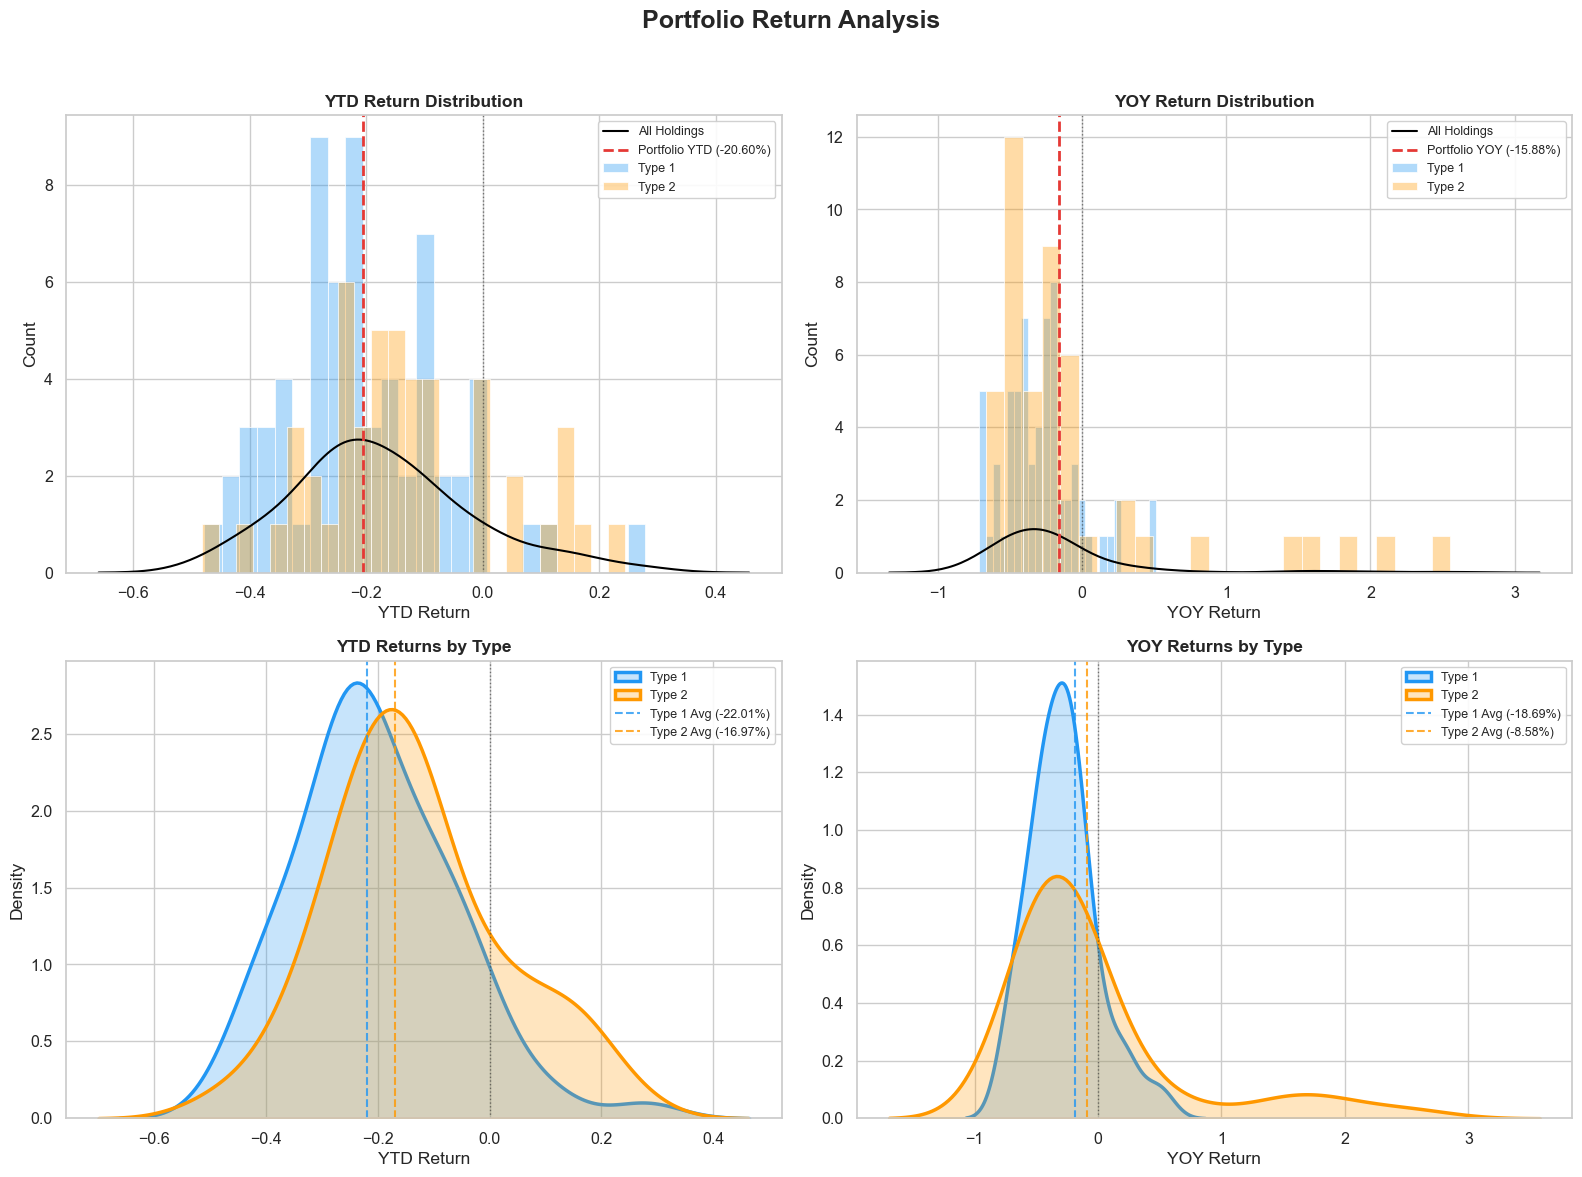

In [128]:
# Visualization

palette = {"type1": "#2196F3", "type2": "#FF9800", "portfolio": "#E53935", "zero": "#333333"}
type1_data = df[df["Type"] == df["Type"].unique()[0]]
type2_data = df[df["Type"] == df["Type"].unique()[1]]
type1_label = f"Type {df['Type'].unique()[0]}"
type2_label = f"Type {df['Type'].unique()[1]}"

sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Portfolio Return Analysis", fontsize=18, fontweight="bold", y=0.98)

# --- Row 1: Overall distributions with type breakdown (histograms + KDE) ---

# Plot 1 – YTD
sns.histplot(type1_data["YTD"], bins=25, kde=False, ax=ax[0, 0], color=palette["type1"], alpha=0.35, label=type1_label, edgecolor="white", linewidth=0.5)
sns.histplot(type2_data["YTD"], bins=25, kde=False, ax=ax[0, 0], color=palette["type2"], alpha=0.35, label=type2_label, edgecolor="white", linewidth=0.5)
sns.kdeplot(df["YTD"], ax=ax[0, 0], color="black", linewidth=1.5, label="All Holdings")
ax[0, 0].axvline(0, color=palette["zero"], linestyle=":", linewidth=1, alpha=0.6)
ax[0, 0].axvline(total_ytd_return, color=palette["portfolio"], linestyle="--", linewidth=2, label=f"Portfolio YTD ({total_ytd_return:.2%})")
ax[0, 0].set_title("YTD Return Distribution", fontweight="bold")
ax[0, 0].set_xlabel("YTD Return")
ax[0, 0].set_ylabel("Count")
ax[0, 0].legend(fontsize=9, framealpha=0.9)

# Plot 2 – YOY
sns.histplot(type1_data["YOY"], bins=25, kde=False, ax=ax[0, 1], color=palette["type1"], alpha=0.35, label=type1_label, edgecolor="white", linewidth=0.5)
sns.histplot(type2_data["YOY"], bins=25, kde=False, ax=ax[0, 1], color=palette["type2"], alpha=0.35, label=type2_label, edgecolor="white", linewidth=0.5)
sns.kdeplot(df["YOY"], ax=ax[0, 1], color="black", linewidth=1.5, label="All Holdings")
ax[0, 1].axvline(0, color=palette["zero"], linestyle=":", linewidth=1, alpha=0.6)
ax[0, 1].axvline(total_yoy_return, color=palette["portfolio"], linestyle="--", linewidth=2, label=f"Portfolio YOY ({total_yoy_return:.2%})")
ax[0, 1].set_title("YOY Return Distribution", fontweight="bold")
ax[0, 1].set_xlabel("YOY Return")
ax[0, 1].set_ylabel("Count")
ax[0, 1].legend(fontsize=9, framealpha=0.9)

# --- Row 2: Type comparison (KDE only, clean overlap) ---

# Compute type-level average returns for reference lines
type1_avg_ytd = type_avg_return.iloc[0]["Weighted YTD Return"]
type2_avg_ytd = type_avg_return.iloc[1]["Weighted YTD Return"]
type1_avg_yoy = type_avg_return.iloc[0]["Weighted YOY Return"]
type2_avg_yoy = type_avg_return.iloc[1]["Weighted YOY Return"]

# Plot 3 – YTD by type
sns.kdeplot(type1_data["YTD"], ax=ax[1, 0], fill=True, alpha=0.25, color=palette["type1"], linewidth=2.5, label=type1_label)
sns.kdeplot(type2_data["YTD"], ax=ax[1, 0], fill=True, alpha=0.25, color=palette["type2"], linewidth=2.5, label=type2_label)
ax[1, 0].axvline(type1_avg_ytd, color=palette["type1"], linestyle="--", linewidth=1.5, alpha=0.8, label=f"{type1_label} Avg ({type1_avg_ytd:.2%})")
ax[1, 0].axvline(type2_avg_ytd, color=palette["type2"], linestyle="--", linewidth=1.5, alpha=0.8, label=f"{type2_label} Avg ({type2_avg_ytd:.2%})")
ax[1, 0].axvline(0, color=palette["zero"], linestyle=":", linewidth=1, alpha=0.6)
ax[1, 0].set_title("YTD Returns by Type", fontweight="bold")
ax[1, 0].set_xlabel("YTD Return")
ax[1, 0].set_ylabel("Density")
ax[1, 0].legend(fontsize=9, framealpha=0.9)

# Plot 4 – YOY by type
sns.kdeplot(type1_data["YOY"], ax=ax[1, 1], fill=True, alpha=0.25, color=palette["type1"], linewidth=2.5, label=type1_label)
sns.kdeplot(type2_data["YOY"], ax=ax[1, 1], fill=True, alpha=0.25, color=palette["type2"], linewidth=2.5, label=type2_label)
ax[1, 1].axvline(type1_avg_yoy, color=palette["type1"], linestyle="--", linewidth=1.5, alpha=0.8, label=f"{type1_label} Avg ({type1_avg_yoy:.2%})")
ax[1, 1].axvline(type2_avg_yoy, color=palette["type2"], linestyle="--", linewidth=1.5, alpha=0.8, label=f"{type2_label} Avg ({type2_avg_yoy:.2%})")
ax[1, 1].axvline(0, color=palette["zero"], linestyle=":", linewidth=1, alpha=0.6)
ax[1, 1].set_title("YOY Returns by Type", fontweight="bold")
ax[1, 1].set_xlabel("YOY Return")
ax[1, 1].set_ylabel("Density")
ax[1, 1].legend(fontsize=9, framealpha=0.9)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()